/tmp/ipython-input-4035978365.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0733273538052212' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  W.loc[i, j] = row['lps']
/tmp/ipython-input-4035978365.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0032534563453104' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  W.loc[i, j] = row['lps']
/tmp/ipython-input-4035978365.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0440477415584526' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  W.loc[i, j] = row['lps']
/tmp/ipython-input-4035978365.py:18: FutureWarning: Setting an item of incompatible dtype is depreca

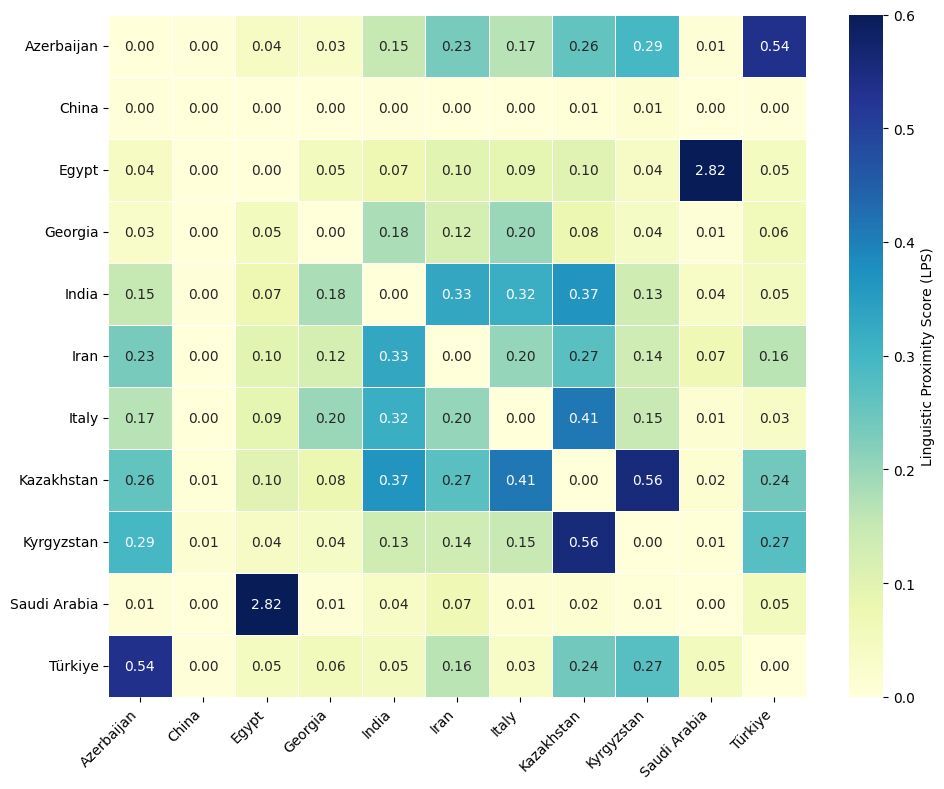

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. خواندن داده و ساخت ماتریس دوطرفه
df = pd.read_excel("language.harvard.xlsx")
df_reverse = df.rename(columns={'country_i': 'country_j', 'country_j': 'country_i'})
df_symmetric = pd.concat([df, df_reverse], ignore_index=True)

countries = sorted(set(df_symmetric['country_i']).union(df_symmetric['country_j']))
W = pd.DataFrame(0, index=countries, columns=countries)

# 2. پر کردن ماتریس W
for _, row in df_symmetric.iterrows():
    i = row['country_i']
    j = row['country_j']
    W.loc[i, j] = row['lps']

# 3. صفر کردن قطر اصلی
#np.fill_diagonal(W.values, 0)

# 4. متقارن‌سازی
W = (W + W.T) / 2

# 5. دوباره صفر کردن قطر (برای اطمینان)
for i in range(W.shape[0]):
    W.iat[i, i] = 0



W_clipped = W.copy()
threshold = 0.6
W_clipped = W_clipped.applymap(lambda x: min(x, threshold))

plt.figure(figsize=(10, 8))
sns.heatmap(
    W_clipped,
    xticklabels=countries,
    yticklabels=countries,
    cmap="YlGnBu",
    annot=W,  # مقدار اصلی برای نمایش عدد
    fmt=".2f",
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Linguistic Proximity Score (LPS)'}
)
#plt.title("Symmetric Linguistic Similarity Matrix (Diagonal elements excluded)", fontsize=14, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np

# 1. خواندن داده اولیه
df = pd.read_excel("language.harvard.xlsx")
df_reverse = df.rename(columns={'country_i': 'country_j', 'country_j': 'country_i'})
df_symmetric = pd.concat([df, df_reverse], ignore_index=True)

# 2. ساخت لیست کشورها
countries = sorted(set(df_symmetric['country_i']).union(df_symmetric['country_j']))
W = pd.DataFrame(0.0, index=countries, columns=countries)

# 3. پر کردن ماتریس شباهت زبانی اولیه
for _, row in df_symmetric.iterrows():
    i = row['country_i']
    j = row['country_j']
    W.loc[i, j] = row['lps']

# 4. متقارن‌سازی
W = (W + W.T) / 2

# 5. صفر کردن قطر اصلی
np.fill_diagonal(W.values, 0)

# 6. نرمال‌سازی سطری
W_row_normalized = W.div(W.sum(axis=1), axis=0).fillna(0)

# اکنون W_row_normalized آماده استفاده در مدل SDM است
# می‌توان آن را ذخیره یا استفاده کرد

W_row_normalized


,Azerbaijan,China,Egypt,Georgia,India,Iran,Italy,Kazakhstan,Kyrgyzstan,Saudi Arabia,Türkiye
Azerbaijan,0.000000,0.001885,0.025516,0.018606,0.087513,0.134720,0.097224,0.150378,0.170015,0.004218,0.309925
China,0.101898,0.000000,0.001391,0.010093,0.117134,0.020947,0.005503,0.188836,0.461141,0.000310,0.092748
Egypt,0.013068,0.000013,0.000000,0.015702,0.021061,0.029116,0.027186,0.030046,0.011582,0.837715,0.014510
Georgia,0.041628,0.000418,0.068594,0.000000,0.231518,0.158343,0.257125,0.103043,0.053181,0.011217,0.074934
India,0.092241,0.002284,0.043344,0.109068,0.000000,0.201233,0.192762,0.223727,0.081855,0.022462,0.031025
Iran,0.143144,0.000412,0.060404,0.075198,0.202858,0.000000,0.124778,0.166044,0.084435,0.043129,0.099596
Italy,0.105895,0.000111,0.057815,0.125174,0.199193,0.127908,0.000000,0.259648,0.093998,0.009372,0.020887
Kazakhstan,0.112461,0.002612,0.043873,0.034443,0.158741,0.116870,0.178280,0.000000,0.241347,0.006913,0.104459
Kyrgyzstan,0.178358,0.008948,0.023724,0.024936,0.081471,0.083366,0.090537,0.338553,0.000000,0.003718,0.166391
Saudi Arabia,0.002398,0.000003,0.929846,0.002850,0.012115,0.023075,0.004891,0.005255,0.002015,0.000000,0.017552


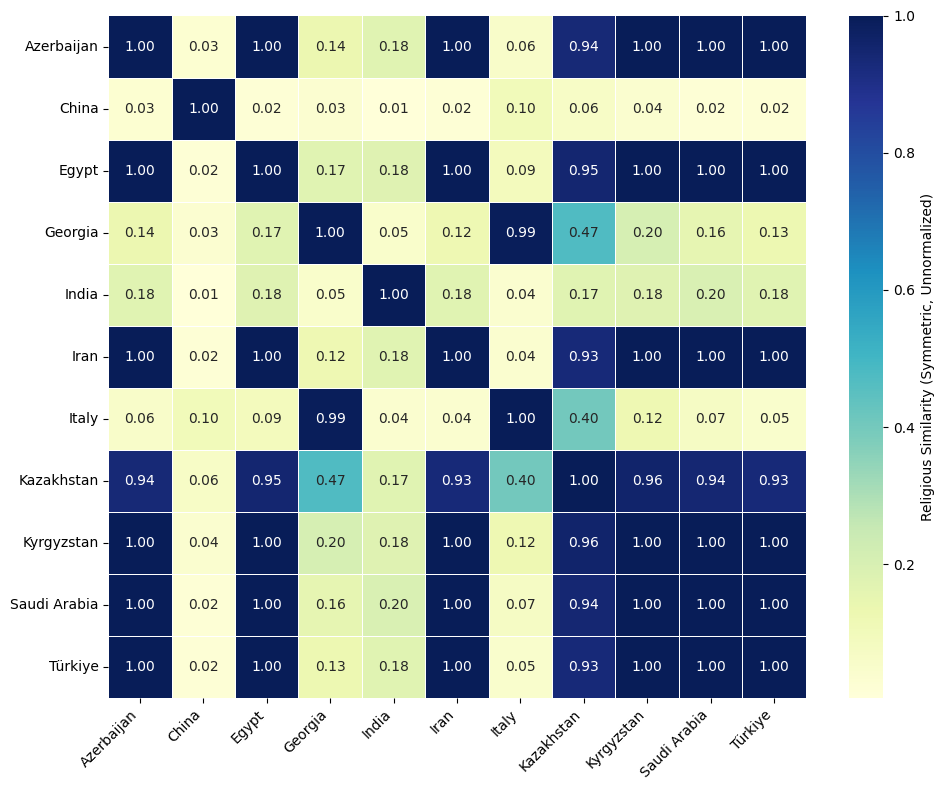

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# خواندن فایل اکسل
df = pd.read_excel('religous.xlsx')

# ستون‌هایی که شامل تعداد جمعیت هر دین هستند
religion_cols = ['Christians', 'Muslims', 'Unaffiliated', 'Hindus', 'Buddhists', 'Other religions', 'Jews']

# نرمال‌سازی سطری: هر مقدار تقسیم بر مجموع آن ردیف
df[religion_cols] = df[religion_cols].div(df[religion_cols].sum(axis=1), axis=0)

# استخراج وکتورهای دینی
vectors = df[religion_cols].values

# مرحله اول: شباهت کسینوس که خودش متقارنه هست
similarity_matrix = cosine_similarity(vectors)

# صفر کردن قطر اصلی برای زیبایی تصویر
#np.fill_diagonal(similarity_matrix, 0)

# این مرحله رو برای نمودار مقاله استفاده کن:
# استفاده از نسخه متقارن و بدون نرمال‌سازی
W_religion_symmetric = similarity_matrix.copy()

# لیست کشورها
countries = df['Country'].tolist()

# رسم Heatmap متقارن برای مقاله
plt.figure(figsize=(10, 8))
sns.heatmap(
    W_religion_symmetric,
    xticklabels=countries,
    yticklabels=countries,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Religious Similarity (Symmetric, Unnormalized)'}
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
# ذخیره تصویر برای مقاله
# plt.savefig("Religious_similarity_heatmap_symmetric.png", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# ساخت ماتریس وزن مناسب برای SDM
W_sdm = similarity_matrix.copy()                  # کپی از شباهت متقارن اولیه
np.fill_diagonal(W_sdm, 0)                        # صفر کردن قطر اصلی
W_sdm = W_sdm / W_sdm.sum(axis=1, keepdims=True)  # نرمال‌سازی سطری (هر ردیف مجموعش 1)

# (اختیاری) ذخیره ماتریس نهایی در فایل CSV برای استفاده در مدلسازی
W_sdm_rel = pd.DataFrame(W_sdm, index=countries, columns=countries)
W_sdm_rel



,Azerbaijan,China,Egypt,Georgia,India,Iran,Italy,Kazakhstan,Kyrgyzstan,Saudi Arabia,Türkiye
Azerbaijan,0.000000,0.004613,0.157800,0.021738,0.027863,0.157887,0.008880,0.147919,0.157554,0.157847,0.157899
China,0.083674,0.000000,0.054251,0.097746,0.016071,0.050519,0.294975,0.183155,0.108066,0.055288,0.056255
Egypt,0.155997,0.002956,0.000000,0.027138,0.027593,0.155901,0.014341,0.148073,0.156013,0.156052,0.155938
Georgia,0.055613,0.013785,0.070231,0.000000,0.020551,0.049447,0.401644,0.191819,0.082451,0.062969,0.051489
India,0.130790,0.004159,0.131019,0.037707,0.000000,0.130139,0.028632,0.128960,0.132085,0.146025,0.130484
Iran,0.159191,0.002808,0.159004,0.019487,0.027953,0.000000,0.006387,0.148212,0.158649,0.159094,0.159216
Italy,0.028558,0.052294,0.046652,0.504879,0.019616,0.020371,0.000000,0.204285,0.062810,0.037515,0.023020
Kazakhstan,0.138473,0.009452,0.140219,0.070188,0.025719,0.137611,0.059465,0.000000,0.141659,0.139323,0.137891
Kyrgyzstan,0.153713,0.005812,0.153969,0.031442,0.027453,0.153514,0.019054,0.147634,0.000000,0.153828,0.153581
Saudi Arabia,0.156557,0.003023,0.156565,0.024411,0.030854,0.156501,0.011570,0.147610,0.156383,0.000000,0.156526


In [10]:
alpha = 0.5 # وزن زبان

W_combinedـ05 = 0.5 * W_row_normalized + 0.5 * W_sdm_rel
W_combinedـ06 = 0.6 * W_row_normalized + 0.4 * W_sdm_rel
W_combinedـ04 = 0.4 * W_row_normalized + 0.6 * W_sdm_rel

# ردیف‌نرمال کردن
W_combined_normalizedـ05 = W_combinedـ05.div(W_combinedـ05.sum(axis=1), axis=0)
W_combined_normalized_06 = W_combinedـ06.div(W_combinedـ06.sum(axis=1), axis=0)
W_combined_normalized_04 = W_combinedـ04.div(W_combinedـ04.sum(axis=1), axis=0)


W_combined_normalizedـ05

,Azerbaijan,China,Egypt,Georgia,India,Iran,Italy,Kazakhstan,Kyrgyzstan,Saudi Arabia,Türkiye
Azerbaijan,0.000000,0.003249,0.091658,0.020172,0.057688,0.146304,0.053052,0.149149,0.163785,0.081033,0.233912
China,0.092786,0.000000,0.027821,0.053920,0.066603,0.035733,0.150239,0.185995,0.284604,0.027799,0.074501
Egypt,0.084533,0.001485,0.000000,0.021420,0.024327,0.092508,0.020763,0.089059,0.083797,0.496883,0.085224
Georgia,0.048621,0.007101,0.069413,0.000000,0.126035,0.103895,0.329385,0.147431,0.067816,0.037093,0.063211
India,0.111515,0.003221,0.087181,0.073388,0.000000,0.165686,0.110697,0.176344,0.106970,0.084244,0.080754
Iran,0.151168,0.001610,0.109704,0.047342,0.115406,0.000000,0.065582,0.157128,0.121542,0.101111,0.129406
Italy,0.067226,0.026202,0.052234,0.315027,0.109405,0.074140,0.000000,0.231966,0.078404,0.023443,0.021953
Kazakhstan,0.125467,0.006032,0.092046,0.052316,0.092230,0.127241,0.118873,0.000000,0.191503,0.073118,0.121175
Kyrgyzstan,0.166036,0.007380,0.088846,0.028189,0.054462,0.118440,0.054795,0.243093,0.000000,0.078773,0.159986
Saudi Arabia,0.079477,0.001513,0.543205,0.013631,0.021485,0.089788,0.008231,0.076432,0.079199,0.000000,0.087039


In [11]:
import pandas as pd

# خواندن فایل CSV
df_sorted = pd.read_excel('FINAL_WIDE_W_14020317.xlsx')

# نمایش چند سطر اول برای اطمینان از درست خواندن
df_sorted

,country,year,GDP,inbound,Political Stability,exchange rate,Airtran,politunesco,Rule of Law: Estimate,unesco
0,Azerbaijan,2002,8.79,13.63,-1.19,-0.03,13.26,-5.93,-0.96,5.0
1,Azerbaijan,2003,8.88,13.85,-0.95,-0.02,13.44,-4.74,-0.88,5.0
2,Azerbaijan,2004,8.96,14.06,-1.06,-0.02,13.82,-5.30,-0.90,5.0
3,Azerbaijan,2005,9.20,13.98,-1.12,-0.06,13.94,-5.62,-0.79,5.0
4,Azerbaijan,2006,9.49,13.99,-1.09,-0.11,14.04,-5.46,-0.89,5.0
...,...,...,...,...,...,...,...,...,...,...
193,Türkiye,2015,10.16,17.53,-1.50,1.00,18.39,-11.96,-0.23,8.0
194,Türkiye,2016,10.18,17.25,-2.01,1.11,18.42,-16.06,-0.34,8.0
195,Türkiye,2017,10.23,17.45,-1.79,1.29,18.50,-14.29,-0.32,8.0
196,Türkiye,2018,10.25,17.65,-1.32,1.57,18.57,-10.52,-0.39,8.0


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_sorted['ps_x_unesco_scaled'] = scaler.fit_transform(df_sorted[['politunesco']])

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


# نرمال‌سازی تعداد سایت‌های یونسکو به بازه [0,1]
df_sorted['unesco_scaled'] = scaler.fit_transform(df_sorted[['unesco']])

df_sorted['rulelaw_scaled'] = (df_sorted['Rule of Law: Estimate'] - df_sorted['Rule of Law: Estimate'].mean()) / df_sorted['Rule of Law: Estimate'].std()

df_sorted['unesco_x_rulelaw'] = df_sorted['unesco_scaled'] * df_sorted['rulelaw_scaled']


df_sorted


,country,year,GDP,inbound,Political Stability,exchange rate,Airtran,politunesco,Rule of Law: Estimate,unesco,ps_x_unesco_scaled,unesco_scaled,rulelaw_scaled,unesco_x_rulelaw
0,Azerbaijan,2002,8.79,13.63,-1.19,-0.03,13.26,-5.93,-0.96,5.0,0.191522,0.035088,-1.100855,-0.038626
1,Azerbaijan,2003,8.88,13.85,-0.95,-0.02,13.44,-4.74,-0.88,5.0,0.252385,0.035088,-0.944155,-0.033128
2,Azerbaijan,2004,8.96,14.06,-1.06,-0.02,13.82,-5.30,-0.90,5.0,0.223744,0.035088,-0.983330,-0.034503
3,Azerbaijan,2005,9.20,13.98,-1.12,-0.06,13.94,-5.62,-0.79,5.0,0.207377,0.035088,-0.767868,-0.026943
4,Azerbaijan,2006,9.49,13.99,-1.09,-0.11,14.04,-5.46,-0.89,5.0,0.215560,0.035088,-0.963743,-0.033816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Türkiye,2015,10.16,17.53,-1.50,1.00,18.39,-11.96,-0.23,8.0,-0.116882,0.087719,0.329030,0.028862
194,Türkiye,2016,10.18,17.25,-2.01,1.11,18.42,-16.06,-0.34,8.0,-0.326576,0.087719,0.113568,0.009962
195,Türkiye,2017,10.23,17.45,-1.79,1.29,18.50,-14.29,-0.32,8.0,-0.236049,0.087719,0.152743,0.013398
196,Türkiye,2018,10.25,17.65,-1.32,1.57,18.57,-10.52,-0.39,8.0,-0.043233,0.087719,0.015630,0.001371


In [25]:
W_05 = W_combined_normalizedـ05  # ماتریس وزن ثابت N×N
W_06 = W_combined_normalized_06  # ماتریس وزن ثابت N×N
W_04 = W_combined_normalized_04  # ماتریس وزن ثابت N×N
W_05

,Azerbaijan,China,Egypt,Georgia,India,Iran,Italy,Kazakhstan,Kyrgyzstan,Saudi Arabia,Türkiye
Azerbaijan,0.000000,0.003249,0.091658,0.020172,0.057688,0.146304,0.053052,0.149149,0.163785,0.081033,0.233912
China,0.092786,0.000000,0.027821,0.053920,0.066603,0.035733,0.150239,0.185995,0.284604,0.027799,0.074501
Egypt,0.084533,0.001485,0.000000,0.021420,0.024327,0.092508,0.020763,0.089059,0.083797,0.496883,0.085224
Georgia,0.048621,0.007101,0.069413,0.000000,0.126035,0.103895,0.329385,0.147431,0.067816,0.037093,0.063211
India,0.111515,0.003221,0.087181,0.073388,0.000000,0.165686,0.110697,0.176344,0.106970,0.084244,0.080754
Iran,0.151168,0.001610,0.109704,0.047342,0.115406,0.000000,0.065582,0.157128,0.121542,0.101111,0.129406
Italy,0.067226,0.026202,0.052234,0.315027,0.109405,0.074140,0.000000,0.231966,0.078404,0.023443,0.021953
Kazakhstan,0.125467,0.006032,0.092046,0.052316,0.092230,0.127241,0.118873,0.000000,0.191503,0.073118,0.121175
Kyrgyzstan,0.166036,0.007380,0.088846,0.028189,0.054462,0.118440,0.054795,0.243093,0.000000,0.078773,0.159986
Saudi Arabia,0.079477,0.001513,0.543205,0.013631,0.021485,0.089788,0.008231,0.076432,0.079199,0.000000,0.087039


In [19]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd

# فرض: df_sorted، X، y، W_dict، countries و years از قبل آماده‌سازی شده‌اند.
# فرض می‌کنیم X ماتریس متغیرهای مستقل است، مثلاً:
X = df_sorted[['GDP', 'Political Stability', 'exchange rate',"Rule of Law: Estimate","unesco_x_rulelaw"]].values


K = X.shape[1]  # تعداد متغیرهای مستقل
N = df_sorted.shape[0]  # تعداد کل ردیف‌های داده (نمونه‌ها)
y = df_sorted['inbound'].values


# نگاشت ایندکس‌ها
country_to_idx = {c: i for i, c in enumerate(sorted(df_sorted['country'].unique()))}
year_to_idx = {y: i for i, y in enumerate(sorted(df_sorted['year'].unique()))}

N = len(country_to_idx)
T = len(year_to_idx)
K = X.shape[1]

# ساخت Wy و WX
y_neighbors = []
WX = np.zeros((N * T, K))

for idx, row in df_sorted.iterrows():
    year = row['year']
    country = row['country']
    c_idx = country_to_idx[country]
    y_idx = year_to_idx[year]
    obs_idx = y_idx * N + c_idx

    # ماتریس وزنی سال

    # مقادیر y سال جاری
    df_year = df_sorted[df_sorted['year'] == year].set_index('country')

    # اطمینان از اینکه همه کشورها با ترتیب countries_sorted در ایندکس هستند
    # و جای خالی‌ها را با 0 پر می‌کنیم
    countries_sorted = sorted(df_sorted['country'].unique()) # Define countries_sorted here
    df_year = df_year.reindex(countries_sorted, fill_value=0)

    y_t = df_year['inbound'].values

    # محاسبه Wy برای کشور c_idx در سال y_idx
    # از iloc برای دسترسی به سطر ماتریس W بر اساس موقعیت عددی استفاده می‌کنیم
    wy = np.dot(W_05.iloc[c_idx], y_t)
    y_neighbors.append(wy)

    # WX
    X_t = X[y_idx * N:(y_idx + 1) * N]
    WX[obs_idx] = np.dot(W_05.iloc[c_idx], X_t) # همچنین از iloc برای دسترسی به سطر ماتریس W استفاده می‌کنیم

y_neighbors = np.array(y_neighbors)

# ایندکس کشورها برای اثرات ثابت
country_idx = pd.Categorical(df_sorted['country']).codes

# ✅ ساخت مدل بیزین SDM با PyMC
with pm.Model() as sdm_model:
    # Priors
    beta = pm.Normal("beta", mu=0, sigma=10, shape=K)
    gamma = pm.Normal("gamma", mu=0, sigma=10, shape=K)
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=N)
    rho = pm.Normal("rho", mu=0, sigma=1)
    sigma = pm.HalfCauchy("sigma", beta=2)

    # مدل خطی فضایی
    mu = (pm.math.dot(X, beta)
          + pm.math.dot(WX, gamma)
          + alpha[country_idx]
          + rho * y_neighbors)

    # مدل نرمال برای متغیر وابسته
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Sampling
    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True ,  idata_kwargs={"log_likelihood": True})


Output()

In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd

# فرض: df_sorted، X، y، W_dict، countries و years از قبل آماده‌سازی شده‌اند.
# فرض می‌کنیم X ماتریس متغیرهای مستقل است، مثلاً:
X = df_sorted[['GDP', 'Political Stability', 'exchange rate',"Rule of Law: Estimate","unesco_x_rulelaw"]].values


K = X.shape[1]  # تعداد متغیرهای مستقل
N = df_sorted.shape[0]  # تعداد کل ردیف‌های داده (نمونه‌ها)
y = df_sorted['inbound'].values


# نگاشت ایندکس‌ها
country_to_idx = {c: i for i, c in enumerate(sorted(df_sorted['country'].unique()))}
year_to_idx = {y: i for i, y in enumerate(sorted(df_sorted['year'].unique()))}

N = len(country_to_idx)
T = len(year_to_idx)
K = X.shape[1]

# ساخت Wy و WX
y_neighbors = []
WX = np.zeros((N * T, K))

for idx, row in df_sorted.iterrows():
    year = row['year']
    country = row['country']
    c_idx = country_to_idx[country]
    y_idx = year_to_idx[year]
    obs_idx = y_idx * N + c_idx

    # ماتریس وزنی سال

    # مقادیر y سال جاری
    df_year = df_sorted[df_sorted['year'] == year].set_index('country')

    # اطمینان از اینکه همه کشورها با ترتیب countries_sorted در ایندکس هستند
    # و جای خالی‌ها را با 0 پر می‌کنیم
    countries_sorted = sorted(df_sorted['country'].unique()) # Define countries_sorted here
    df_year = df_year.reindex(countries_sorted, fill_value=0)

    y_t = df_year['inbound'].values

    # محاسبه Wy برای کشور c_idx در سال y_idx
    # از iloc برای دسترسی به سطر ماتریس W بر اساس موقعیت عددی استفاده می‌کنیم
    wy = np.dot(W_06.iloc[c_idx], y_t)
    y_neighbors.append(wy)

    # WX
    X_t = X[y_idx * N:(y_idx + 1) * N]
    WX[obs_idx] = np.dot(W_06.iloc[c_idx], X_t) # همچنین از iloc برای دسترسی به سطر ماتریس W استفاده می‌کنیم

y_neighbors = np.array(y_neighbors)

# ایندکس کشورها برای اثرات ثابت
country_idx = pd.Categorical(df_sorted['country']).codes

# ✅ ساخت مدل بیزین SDM با PyMC
with pm.Model() as sdm_model:
    # Priors
    beta = pm.Normal("beta", mu=0, sigma=10, shape=K)
    gamma = pm.Normal("gamma", mu=0, sigma=10, shape=K)
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=N)
    rho = pm.Normal("rho", mu=0, sigma=1)
    sigma = pm.HalfCauchy("sigma", beta=2)

    # مدل خطی فضایی
    mu = (pm.math.dot(X, beta)
          + pm.math.dot(WX, gamma)
          + alpha[country_idx]
          + rho * y_neighbors)

    # مدل نرمال برای متغیر وابسته
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Sampling
    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True ,  idata_kwargs={"log_likelihood": True})

Output()

In [ ]:
# خلاصه پارامترها
summary = az.summary(trace, var_names=["rho", "beta", "gamma", "sigma", "alpha"], round_to=4)
print(summary)

# نمودارهای تشخیصی
az.plot_trace(trace, var_names=["rho", "beta", "gamma"])
az.plot_posterior(trace, var_names=["rho", "gamma"])
summary

In [28]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd

# فرض: df_sorted، X، y، W_dict، countries و years از قبل آماده‌سازی شده‌اند.
# فرض می‌کنیم X ماتریس متغیرهای مستقل است، مثلاً:
X = df_sorted[['GDP', 'Political Stability', 'exchange rate',"Rule of Law: Estimate","unesco_x_rulelaw"]].values


K = X.shape[1]  # تعداد متغیرهای مستقل
N = df_sorted.shape[0]  # تعداد کل ردیف‌های داده (نمونه‌ها)
y = df_sorted['inbound'].values


# نگاشت ایندکس‌ها
country_to_idx = {c: i for i, c in enumerate(sorted(df_sorted['country'].unique()))}
year_to_idx = {y: i for i, y in enumerate(sorted(df_sorted['year'].unique()))}

N = len(country_to_idx)
T = len(year_to_idx)
K = X.shape[1]

# ساخت Wy و WX
y_neighbors = []
WX = np.zeros((N * T, K))

for idx, row in df_sorted.iterrows():
    year = row['year']
    country = row['country']
    c_idx = country_to_idx[country]
    y_idx = year_to_idx[year]
    obs_idx = y_idx * N + c_idx

    # ماتریس وزنی سال

    # مقادیر y سال جاری
    df_year = df_sorted[df_sorted['year'] == year].set_index('country')

    # اطمینان از اینکه همه کشورها با ترتیب countries_sorted در ایندکس هستند
    # و جای خالی‌ها را با 0 پر می‌کنیم
    countries_sorted = sorted(df_sorted['country'].unique()) # Define countries_sorted here
    df_year = df_year.reindex(countries_sorted, fill_value=0)

    y_t = df_year['inbound'].values

    # محاسبه Wy برای کشور c_idx در سال y_idx
    # از iloc برای دسترسی به سطر ماتریس W بر اساس موقعیت عددی استفاده می‌کنیم
    wy = np.dot(W_04.iloc[c_idx], y_t)
    y_neighbors.append(wy)

    # WX
    X_t = X[y_idx * N:(y_idx + 1) * N]
    WX[obs_idx] = np.dot(W_04.iloc[c_idx], X_t) # همچنین از iloc برای دسترسی به سطر ماتریس W استفاده می‌کنیم

y_neighbors = np.array(y_neighbors)

# ایندکس کشورها برای اثرات ثابت
country_idx = pd.Categorical(df_sorted['country']).codes

# ✅ ساخت مدل بیزین SDM با PyMC
with pm.Model() as sdm_model:
    # Priors
    beta = pm.Normal("beta", mu=0, sigma=10, shape=K)
    gamma = pm.Normal("gamma", mu=0, sigma=10, shape=K)
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=N)
    rho = pm.Normal("rho", mu=0, sigma=1)
    sigma = pm.HalfCauchy("sigma", beta=2)

    # مدل خطی فضایی
    mu = (pm.math.dot(X, beta)
          + pm.math.dot(WX, gamma)
          + alpha[country_idx]
          + rho * y_neighbors)

    # مدل نرمال برای متغیر وابسته
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Sampling
    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True ,  idata_kwargs={"log_likelihood": True})

Output()

             mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
rho        0.5115  0.1080  0.3101   0.7256     0.0032   0.0026  1144.4395   
beta[0]    0.5784  0.1833  0.2357   0.9198     0.0056   0.0043  1062.3816   
beta[1]    0.3520  0.1160  0.1362   0.5682     0.0026   0.0025  2053.6620   
beta[2]    0.1172  0.0790 -0.0277   0.2657     0.0024   0.0020  1098.9598   
beta[3]    0.7037  0.1794  0.3649   1.0309     0.0044   0.0034  1632.1025   
beta[4]   -0.8754  0.2681 -1.3424  -0.3637     0.0073   0.0057  1346.3734   
gamma[0]   0.2564  0.0830  0.0936   0.4036     0.0020   0.0016  1747.1143   
gamma[1]  -0.1268  0.1478 -0.4053   0.1549     0.0034   0.0032  1938.3257   
gamma[2]   0.0613  0.0391 -0.0104   0.1325     0.0009   0.0009  1988.1053   
gamma[3]   0.1520  0.1928 -0.2236   0.4979     0.0045   0.0045  1824.5068   
gamma[4]   0.2349  0.1658 -0.0678   0.5516     0.0041   0.0035  1658.9412   
sigma      0.3754  0.0211  0.3368   0.4133     0.0004   0.0004  2209.4504   

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho,0.5115,0.1080,0.3101,0.7256,0.0032,0.0026,1144.4395,1144.7765,1.0013
beta[0],0.5784,0.1833,0.2357,0.9198,0.0056,0.0043,1062.3816,829.8680,1.0000
beta[1],0.3520,0.1160,0.1362,0.5682,0.0026,0.0025,2053.6620,1375.7959,0.9995
beta[2],0.1172,0.0790,-0.0277,0.2657,0.0024,0.0020,1098.9598,1182.4084,1.0009
beta[3],0.7037,0.1794,0.3649,1.0309,0.0044,0.0034,1632.1025,1356.0646,1.0032
beta[4],-0.8754,0.2681,-1.3424,-0.3637,0.0073,0.0057,1346.3734,1306.3829,1.0019
gamma[0],0.2564,0.0830,0.0936,0.4036,0.0020,0.0016,1747.1143,1528.0149,1.0011
gamma[1],-0.1268,0.1478,-0.4053,0.1549,0.0034,0.0032,1938.3257,1464.1531,1.0005
gamma[2],0.0613,0.0391,-0.0104,0.1325,0.0009,0.0009,1988.1053,1527.5228,1.0009
gamma[3],0.1520,0.1928,-0.2236,0.4979,0.0045,0.0045,1824.5068,1182.4500,1.0038


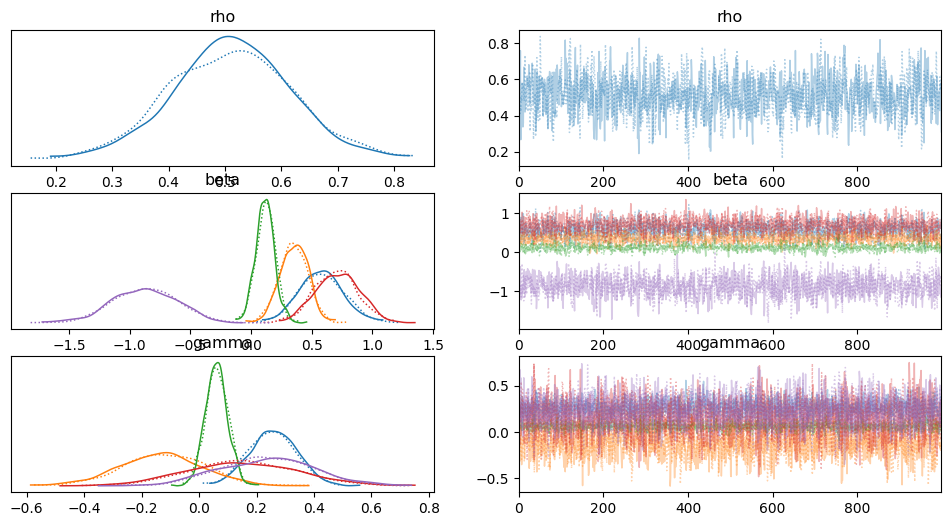

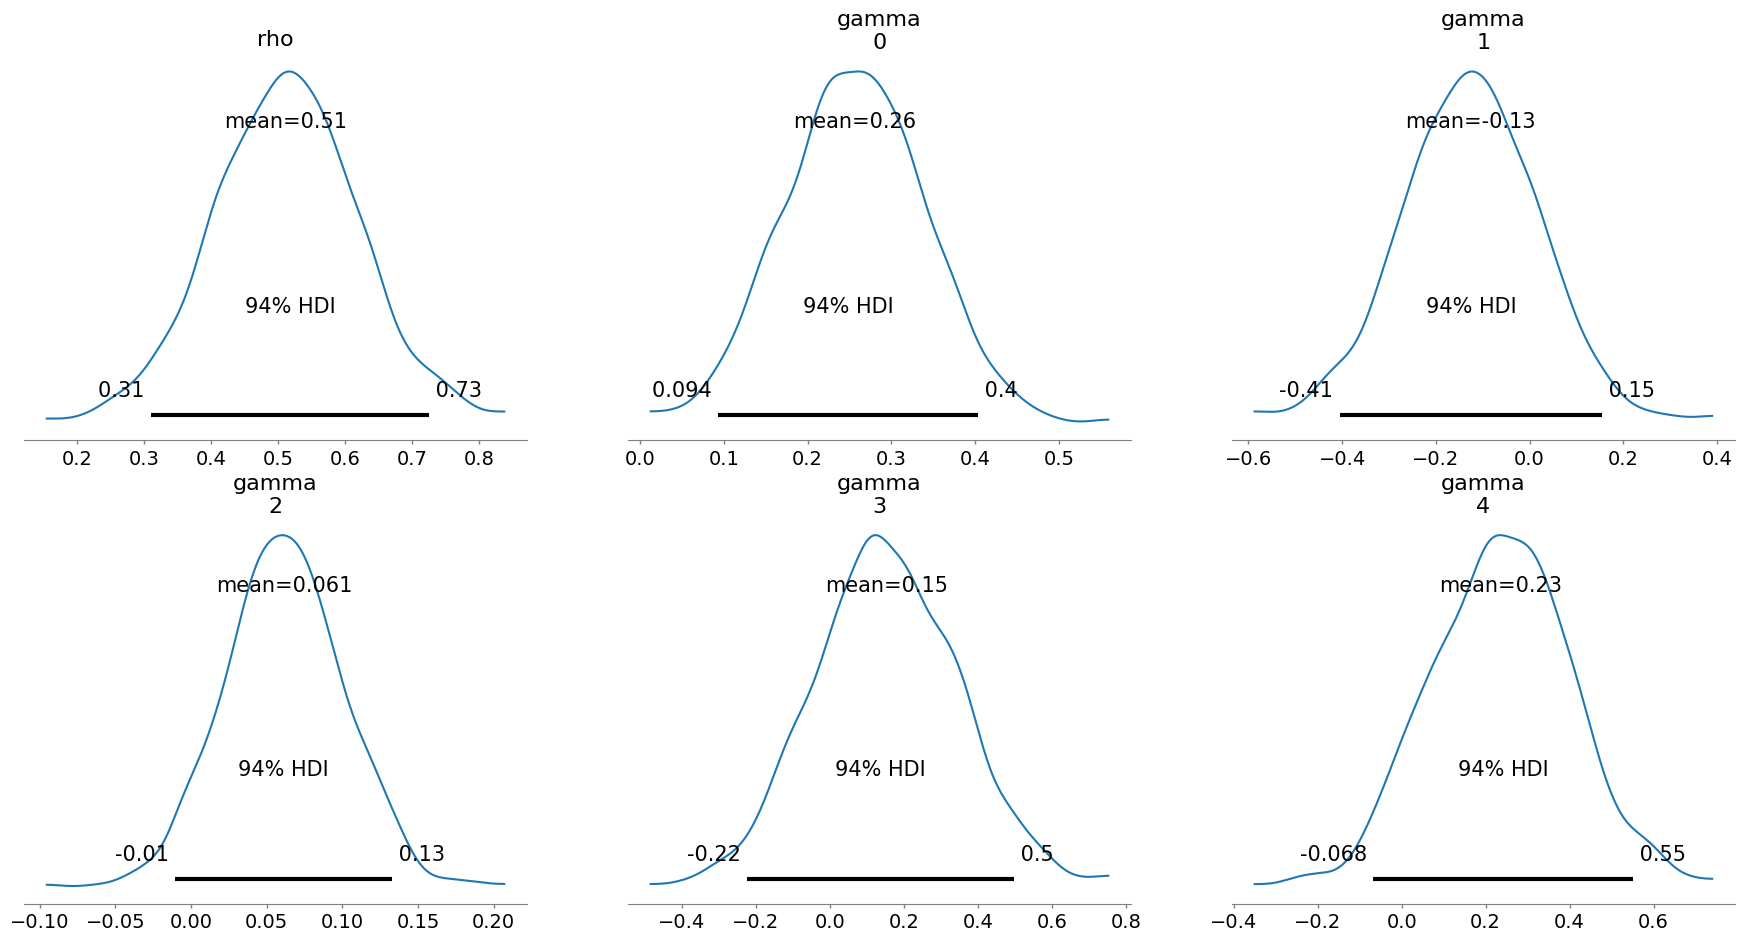

In [29]:
# خلاصه پارامترها
summary = az.summary(trace, var_names=["rho", "beta", "gamma", "sigma", "alpha"], round_to=4)
print(summary)

# نمودارهای تشخیصی
az.plot_trace(trace, var_names=["rho", "beta", "gamma"])
az.plot_posterior(trace, var_names=["rho", "gamma"])
summary

In [ ]:

waic = az.waic(trace)
loo = az.loo(trace)

print("WAIC elpd:", waic.elpd_waic)
print("WAIC p:", waic.p_waic)
print("LOO elpd:", loo.elpd_loo)
print("LOO p:", loo.p_loo)

In [ ]:
loo_result = az.loo(trace)
az.plot_khat(loo_result)


In [ ]:
loo_result = az.loo(trace, pointwise=True)
k_values = loo_result.pareto_k.values

# پیدا کردن ایندکس‌هایی که k > 0.7 دارند
import numpy as np
outliers = np.where(k_values > 0.7)[0]
print("Index of influential observations:", outliers)


In [ ]:
obs_idx = y_idx * N + c_idx

In [ ]:
N = 11
obs_idx = 144
year_index = 144 // 11  # تقسیم صحیح
country_index = 144 % 11

In [ ]:
year_val = list(year_to_idx.keys())[list(year_to_idx.values()).index(year_index)]
country_val = list(country_to_idx.keys())[list(country_to_idx.values()).index(country_index)]

print(f"Influential observation at year: {year_val}, country: {country_val}")

مدل مقاوم تر با توزیع t

In [ ]:
import pymc as pm

with pm.Model() as model2:
    # ... تعریف priors متغیرهای مدل ...

    # Priors
    beta = pm.Normal("beta", mu=0, sigma=10, shape=K)
    gamma = pm.Normal("gamma", mu=0, sigma=10, shape=K)
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=N)
    rho = pm.Normal("rho", mu=0, sigma=1)
    sigma_t = pm.HalfNormal('sigma_t', 1)


    # مدل خطی فضایی
    mu = (pm.math.dot(X, beta)
          + pm.math.dot(WX, gamma)
          + alpha[country_idx]
          + rho * y_neighbors)

    nu = pm.Exponential('nu', 1/30)  # درجه آزادی توزیع t، معمولا بین 2 تا 30

    y_obs1 = pm.StudentT('y_obs1', mu=mu, sigma=sigma_t, nu=nu, observed=y)

        # Sampling
    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True ,  idata_kwargs={"log_likelihood": True})

In [ ]:

waic = az.waic(trace)
loo = az.loo(trace)

print("WAIC elpd:", waic.elpd_waic)
print("WAIC p:", waic.p_waic)
print("LOO elpd:", loo.elpd_loo)
print("LOO p:", loo.p_loo)

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# داده‌ها: df_sorted و ستون‌های X که انتخاب کردی
X_df = df_sorted[['GDP', 'Political Stability', 'exchange rate', "Airtran", "Rule of Law: Estimate", "unesco_x_rulelaw"]]

# محاسبه ماتریس همبستگی
corr_matrix = X_df.corr()
print("Correlation matrix:")
print(corr_matrix)

# محاسبه VIF
# ابتدا باید آرایه numpy
X_np = X_df.values

vif_data = pd.DataFrame()
vif_data["feature"] = X_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_np, i) for i in range(X_np.shape[1])]

print("\nVariance Inflation Factor (VIF):")
print(vif_data)
